# 03 — Feature derivation

A separate feature set for each branch, chosen on the training period only
(March 2000 to December 2021). Only lagged values are used, so every predictor is
known before the month being forecast; the calendar month is the one exception.

| Stage | Candidates | Rule |
|---|---|---|
| 1 | own lags 1–24, rolling means, calendar | lasso, time-series CV, one-standard-error rule |
| 2 | LST and SPEI 1/3/6/12 at lags 1–12 | correlation with stage-1 residual, `n_eff` and Bonferroni corrected, plausible sign |
| 3 | probes and family representatives | LST lag 1 as negative control, Gaussian noise; strongest plausible SPEI lag where none passed |

Input: `data/processed/orchard_decomposed.csv`
Output: `data/processed/features_*.csv`, `results/feature_registry.csv`

In [1]:
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import Lasso, LassoCV, LinearRegression
from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore", category=ConvergenceWarning)

d = pd.read_csv("../data/processed/orchard_decomposed.csv",
                index_col="date", parse_dates=True)

TRAIN_END = pd.Timestamp("2021-12-01")
BRANCHES = {"original": "", "seasonal": "_S", "trend": "_T"}
MAX_OWN_LAG, MAX_CLIMATE_LAG = 24, 12

# expected sign of a physically plausible relationship with NDVI:
# hotter than usual -> less green; wetter than usual (higher SPEI) -> greener
CLIMATE = {"LST": -1, "SPEI_1": +1, "SPEI_3": +1, "SPEI_6": +1, "SPEI_12": +1}

train = d[d.index <= TRAIN_END]
print(f"full record {d.index.min():%Y-%m} -> {d.index.max():%Y-%m}  ({len(d)} months)")
print(f"training    {train.index.min():%Y-%m} -> {train.index.max():%Y-%m}  ({len(train)} months)")
print(f"test        {TRAIN_END + pd.DateOffset(months=1):%Y-%m} -> "
      f"{d.index.max():%Y-%m}  ({len(d) - len(train)} months)")

full record 2000-03 -> 2024-12  (298 months)
training    2000-03 -> 2021-12  (262 months)
test        2022-01 -> 2024-12  (36 months)


## Stage 1 — own history

A linear time index is excluded: tree models cannot extrapolate it, so it would act
as a different feature in different model classes.

In [2]:
def own_history(df, y, name):
    """Candidate predictors built from the target's own past, plus the calendar."""
    C = pd.DataFrame(index=df.index)
    for k in range(1, MAX_OWN_LAG + 1):
        C[f"{name}_lag{k}"] = y.shift(k)
    for w in (3, 6, 12):
        C[f"{name}_roll{w}"] = y.shift(1).rolling(w).mean()
    month = df.index.month
    C["month_sin"] = np.sin(2 * np.pi * month / 12)
    C["month_cos"] = np.cos(2 * np.pi * month / 12)
    return C


def lasso_1se(y, C):
    """Lasso, time-series CV, one-standard-error rule. Returns the selected columns."""
    D = pd.concat([y.rename("y"), C], axis=1).dropna()
    X = StandardScaler().fit_transform(D[C.columns])
    cv = LassoCV(cv=TimeSeriesSplit(5), alphas=200, max_iter=200_000).fit(X, D["y"])
    mse = cv.mse_path_.mean(axis=1)
    se = cv.mse_path_.std(axis=1) / np.sqrt(cv.mse_path_.shape[1])
    best = mse.argmin()
    alpha_1se = cv.alphas_[mse <= mse[best] + se[best]].max()
    coef = Lasso(alpha=alpha_1se, max_iter=200_000).fit(X, D["y"]).coef_
    return [c for c, b in zip(C.columns, coef) if b != 0]


def select_own(train_df):
    out = {}
    for branch, suf in BRANCHES.items():
        y = train_df[f"NDVI{suf}"]
        out[branch] = lasso_1se(y, own_history(train_df, y, f"NDVI{suf}"))
    return out


own = select_own(train)
for branch, cols in own.items():
    print(f"{branch:9s} {len(cols):2d} selected: {cols}")

original   9 selected: ['NDVI_lag1', 'NDVI_lag3', 'NDVI_lag11', 'NDVI_lag12', 'NDVI_lag14', 'NDVI_lag18', 'NDVI_lag23', 'NDVI_lag24', 'month_cos']
seasonal  10 selected: ['NDVI_S_lag1', 'NDVI_S_lag3', 'NDVI_S_lag11', 'NDVI_S_lag12', 'NDVI_S_lag14', 'NDVI_S_lag18', 'NDVI_S_lag23', 'NDVI_S_lag24', 'NDVI_S_roll12', 'month_cos']
trend      3 selected: ['NDVI_T_lag1', 'NDVI_T_lag10', 'NDVI_T_lag24']


### Selected lags against the autocorrelation

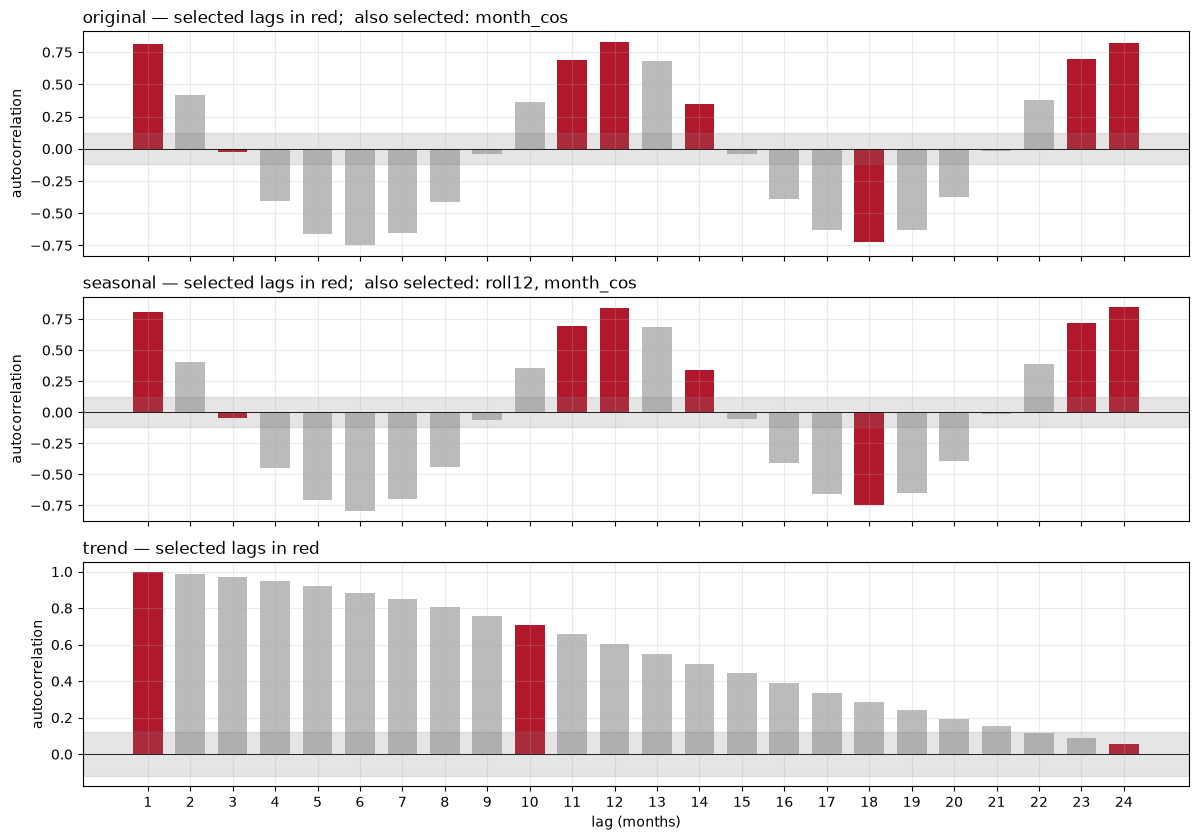

In [3]:
def acf(s, nlags):
    s = s.dropna() - s.dropna().mean()
    v = s.to_numpy()
    return np.array([(v[k:] * v[:-k]).sum() / (v * v).sum() for k in range(1, nlags + 1)])


fig, axes = plt.subplots(3, 1, figsize=(12, 8.5), sharex=True)
lags = np.arange(1, MAX_OWN_LAG + 1)
for ax, (branch, suf) in zip(axes, BRANCHES.items()):
    y = train[f"NDVI{suf}"]
    a = acf(y, MAX_OWN_LAG)
    chosen = [int(c.split("_lag")[1]) for c in own[branch] if "_lag" in c]
    colors = ["#b2182b" if k in chosen else "#bbbbbb" for k in lags]
    ax.bar(lags, a, color=colors, width=0.7)
    ax.axhline(0, color="black", lw=0.6)
    ci = 1.96 / np.sqrt(y.notna().sum())
    ax.axhspan(-ci, ci, color="grey", alpha=0.2)
    other = [c.replace(f"NDVI{suf}_", "") for c in own[branch] if "_lag" not in c]
    ax.set_title(f"{branch} — selected lags in red"
                 + (f";  also selected: {', '.join(other)}" if other else ""), loc="left")
    ax.set_ylabel("autocorrelation")
    ax.grid(alpha=0.25)
axes[-1].set_xlabel("lag (months)")
axes[-1].set_xticks(lags)
fig.tight_layout()
fig.savefig("../figures/03_own_history.png", dpi=150, bbox_inches="tight")
plt.show()

## Stage 2 — lagged climate

Effective sample size after Bretherton et al. (1999).

In [4]:
Z = norm.ppf(1 - 0.05 / (2 * MAX_CLIMATE_LAG))    # two-sided 5%, Bonferroni over lags


def stage1_residual(df, y, cols, name):
    C = own_history(df, y, name)[cols]
    D = pd.concat([y.rename("y"), C], axis=1).dropna()
    fit = LinearRegression().fit(D[cols], D["y"])
    return pd.Series(D["y"].to_numpy() - fit.predict(D[cols]), index=D.index)


def effective_n(n, r1a, r1b):
    """Bretherton et al. (1999), effective sample size for two autocorrelated series."""
    return n * (1 - r1a * r1b) / (1 + r1a * r1b)


def climate_evidence(train_df, own_sel):
    rows = []
    for branch, suf in BRANCHES.items():
        y = train_df[f"NDVI{suf}"]
        res = stage1_residual(train_df, y, own_sel[branch], f"NDVI{suf}")
        for var, sign in CLIMATE.items():
            x = train_df[f"{var}{suf}"]
            bound = Z / np.sqrt(effective_n(len(res), res.autocorr(1), x.autocorr(1)))
            for lag in range(1, MAX_CLIMATE_LAG + 1):
                r = res.corr(x.shift(lag).reindex(res.index))
                rows.append(dict(branch=branch, variable=var, lag=lag, r=r,
                                 bound=bound, expected=sign))
    ev = pd.DataFrame(rows)
    best = ev.loc[ev.groupby(["branch", "variable"])["r"]
                    .apply(lambda s: s.abs().idxmax())].reset_index(drop=True)
    significant = best["r"].abs() > best["bound"]
    plausible = np.sign(best["r"]) == best["expected"]
    best["decision"] = np.select([significant & plausible, significant],
                                 ["selected", "implausible sign"], "not significant")
    return ev, best


ev, best = climate_evidence(train, own)
print(f"Bonferroni z = {Z:.2f}\n")
print(best.assign(r=best.r.round(3), bound=best.bound.round(3))
          .drop(columns="expected").to_string(index=False))

Bonferroni z = 2.87

  branch variable  lag      r  bound         decision
original      LST    2 -0.059  0.227  not significant
original   SPEI_1   12 -0.173  0.190  not significant
original  SPEI_12    9 -0.114  0.231  not significant
original   SPEI_3    1  0.185  0.214  not significant
original   SPEI_6    1  0.247  0.224         selected
seasonal      LST   12  0.052  0.219  not significant
seasonal   SPEI_1    6  0.153  0.187  not significant
seasonal  SPEI_12   10 -0.250  0.217 implausible sign
seasonal   SPEI_3    5  0.234  0.205         selected
seasonal   SPEI_6    2  0.300  0.212         selected
   trend      LST    7  0.133  0.194  not significant
   trend   SPEI_1   12 -0.152  0.194  not significant
   trend  SPEI_12    9 -0.135  0.194  not significant
   trend   SPEI_3   12 -0.120  0.194  not significant
   trend   SPEI_6   11 -0.117  0.194  not significant


### Correlation with the stage-1 residual, scaled by its bound

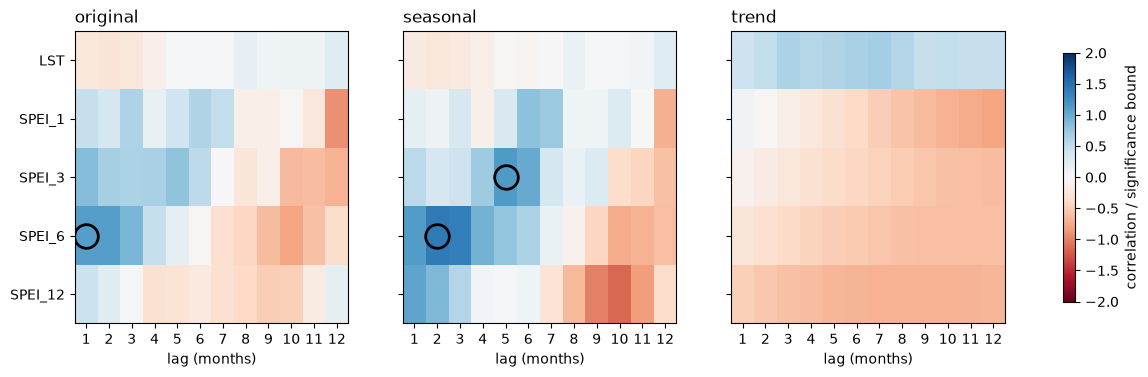

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 3.8), sharey=True)
for ax, branch in zip(axes, BRANCHES):
    sub = ev[ev.branch == branch]
    grid = (sub.assign(z=sub.r / sub.bound)
               .pivot(index="variable", columns="lag", values="z")
               .loc[list(CLIMATE)])
    im = ax.imshow(grid, cmap="RdBu", vmin=-2, vmax=2, aspect="auto")
    ax.set_xticks(range(MAX_CLIMATE_LAG), range(1, MAX_CLIMATE_LAG + 1))
    ax.set_yticks(range(len(CLIMATE)), list(CLIMATE))
    for i, var in enumerate(CLIMATE):
        row = best[(best.branch == branch) & (best.variable == var)].iloc[0]
        if row.decision == "selected":
            ax.plot(row.lag - 1, i, "o", ms=17, mfc="none", mec="black", mew=2)
    ax.set_title(branch, loc="left")
    ax.set_xlabel("lag (months)")
fig.colorbar(im, ax=axes, shrink=0.85, label="correlation / significance bound")
fig.savefig("../figures/03_climate_evidence.png", dpi=150, bbox_inches="tight")
plt.show()

## Stage 3 — probes and family representatives

Random probe after Stoppiglia et al. (2003). Every branch keeps at least one drought
feature: where no SPEI lag passed stage 2, the lag with the strongest plausible-sign
correlation is kept as the family's representative, so stratified selection in
notebook 06 can always choose a drought member. The calendar is not added to the
trend, which has no annual cycle.

In [6]:
NOISE = pd.Series(np.random.default_rng(0).standard_normal(len(d)),
                  index=d.index, name="noise_probe")

climate = {}
for branch, suf in BRANCHES.items():
    chosen = best[(best.branch == branch) & (best.decision == "selected")]
    climate[branch] = [f"{r.variable}{suf}_lag{r.lag}" for r in chosen.itertuples()]

controls = {branch: [f"LST{suf}_lag1"] for branch, suf in BRANCHES.items()
            if f"LST{suf}_lag1" not in climate[branch]}

representatives, rep_evidence = {}, {}
for branch, suf in BRANCHES.items():
    if not any(f.startswith("SPEI") for f in climate[branch]):
        spei = ev[(ev.branch == branch) & ev.variable.str.startswith("SPEI") & (ev.r > 0)]
        top = spei.loc[(spei.r / spei.bound).idxmax()]
        representatives[branch] = [f"{top.variable}{suf}_lag{top.lag}"]
        rep_evidence[branch] = (top.r, top.bound)

for branch in BRANCHES:
    print(f"{branch:9s} climate {climate[branch]}  representative {representatives.get(branch, [])}  "
          f"control {controls.get(branch, [])}  + noise_probe")

original  climate ['SPEI_6_lag1']  representative []  control ['LST_lag1']  + noise_probe
seasonal  climate ['SPEI_3_S_lag5', 'SPEI_6_S_lag2']  representative []  control ['LST_S_lag1']  + noise_probe
trend     climate []  representative ['SPEI_1_T_lag1']  control ['LST_T_lag1']  + noise_probe


## Stability

Selection rerun on data up to December 2013.

In [7]:
early = d[d.index <= pd.Timestamp("2013-12-01")]
own_early = select_own(early)
_, best_early = climate_evidence(early, own_early)


def final_set(own_sel, best_sel, branch):
    suf = BRANCHES[branch]
    clim = best_sel[(best_sel.branch == branch) & (best_sel.decision == "selected")]
    return set(own_sel[branch]) | {f"{r.variable}{suf}_lag{r.lag}" for r in clim.itertuples()}


print(f"{'branch':9s} {'to 2021':>8s} {'to 2013':>8s} {'shared':>7s} {'Jaccard':>8s}")
for branch in BRANCHES:
    a = final_set(own, best, branch)
    b = final_set(own_early, best_early, branch)
    print(f"{branch:9s} {len(a):8d} {len(b):8d} {len(a & b):7d} {len(a & b) / len(a | b):8.2f}")
    if a != b:
        print(f"    only to 2021: {sorted(a - b)}")
        print(f"    only to 2013: {sorted(b - a)}")

branch     to 2021  to 2013  shared  Jaccard
original        10        7       7     0.70
    only to 2021: ['NDVI_lag14', 'NDVI_lag3', 'SPEI_6_lag1']
    only to 2013: []
seasonal        12       11      11     0.92
    only to 2021: ['SPEI_3_S_lag5']
    only to 2013: []
trend            3        2       1     0.25
    only to 2021: ['NDVI_T_lag10', 'NDVI_T_lag24']
    only to 2013: ['NDVI_T_lag14']


## Feature tables and registry

Features are saved unscaled; scaling happens per training window in notebook 04.

In [8]:
def build(branch):
    suf = BRANCHES[branch]
    y = d[f"NDVI{suf}"]
    X = own_history(d, y, f"NDVI{suf}")[own[branch]].copy()
    for feat in climate[branch] + representatives.get(branch, []) + controls.get(branch, []):
        base, lag = feat.rsplit("_lag", 1)
        X[feat] = d[base].shift(int(lag))
    X["noise_probe"] = NOISE
    out = X.assign(target=y).dropna()
    out["split"] = np.where(out.index <= TRAIN_END, "train", "test")
    return out


tables = {}
for branch in BRANCHES:
    tables[branch] = build(branch)
    tables[branch].to_csv(f"../data/processed/features_{branch}.csv")
    t = tables[branch]
    print(f"{branch:9s} {t.shape[1] - 2:2d} features | rows {len(t)} "
          f"({t.index.min():%Y-%m} -> {t.index.max():%Y-%m}) | "
          f"{t.split.value_counts().to_dict()}")

original  12 features | rows 274 (2002-03 -> 2024-12) | {'train': 238, 'test': 36}
seasonal  14 features | rows 274 (2002-03 -> 2024-12) | {'train': 238, 'test': 36}
trend      6 features | rows 274 (2002-03 -> 2024-12) | {'train': 238, 'test': 36}


In [9]:
rows = []
for branch, suf in BRANCHES.items():
    y = train[f"NDVI{suf}"]
    for cand in own_history(train, y, f"NDVI{suf}").columns:
        family = "calendar" if cand.startswith("month") else "own history"
        rows.append(dict(branch=branch, feature=cand, family=family, stage=1,
                         decision="selected" if cand in own[branch] else "not selected",
                         reason="lasso, time-series CV, one-standard-error rule"))
    rows.append(dict(branch=branch, feature="time_index", family="time", stage=1,
                     decision="excluded a priori",
                     reason="not extrapolable by tree models; would differ by model class"))
    for r in best[best.branch == branch].itertuples():
        rows.append(dict(branch=branch, feature=f"{r.variable}{suf}_lag{r.lag}",
                         family="LST" if r.variable == "LST" else "drought",
                         stage=2, decision=r.decision,
                         reason=f"best of lags 1-12: r={r.r:+.3f}, bound {r.bound:.3f}"))
    for feat in representatives.get(branch, []):
        rows.append(dict(branch=branch, feature=feat, family="drought",
                         stage=3, decision="family representative",
                         reason=f"no SPEI lag passed; strongest plausible-sign lag kept "
                                f"(r={rep_evidence[branch][0]:+.3f}, bound {rep_evidence[branch][1]:.3f})"))
    for feat in controls.get(branch, []):
        rows.append(dict(branch=branch, feature=feat, family="LST", stage=3,
                         decision="negative control",
                         reason="no incremental evidence; kept to test attribution"))
    rows.append(dict(branch=branch, feature="noise_probe", family="probe", stage=3,
                     decision="random probe",
                     reason="Gaussian noise, seed 0; true importance zero"))

registry = pd.DataFrame(rows)
registry.to_csv("../results/feature_registry.csv", index=False)

used = registry[registry.decision.isin(["selected", "family representative", "negative control", "random probe"])]
print(f"registry: {len(registry)} candidates recorded, {len(used)} used\n")
print(used.groupby(["branch", "family"]).size().unstack(fill_value=0).to_string())

registry: 112 candidates recorded, 32 used

family    LST  calendar  drought  own history  probe
branch                                              
original    1         1        1            8      1
seasonal    1         1        2            9      1
trend       1         0        1            3      1
